### import

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# import sklearn
# from sklearn import linear_model
from sklearn.linear_model import LinearRegression, SGDRegressor

### load data

In [69]:
df = pd.read_csv('train_advertising_data.csv')
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,0,0.016886,0.440321,-0.837652,0.255143
1,1,-1.209628,1.067664,1.528850,-0.550571
2,2,0.175407,-1.360761,-1.029652,-0.608122
3,3,-1.501214,0.952988,0.617970,-1.221999
4,4,-1.420218,-0.719927,-0.355422,-1.337101
...,...,...,...,...,...
155,155,1.119592,0.777602,-1.163605,1.348611
156,156,-0.946969,-0.726672,0.524203,-0.761591
157,157,1.691194,1.364471,1.805686,2.403712
158,158,0.936772,-1.306796,-0.815327,-0.416285


In [70]:
train_set = np.array(df)

In [71]:
train_set.shape

(160, 5)

### split_data

In [72]:
x_train = train_set[:,1:4]
y_train = train_set[:,4]
x_train.shape, y_train.shape

((160, 3), (160,))

### plots

Text(0.5, 1.0, 'Newspaper vs Salea')

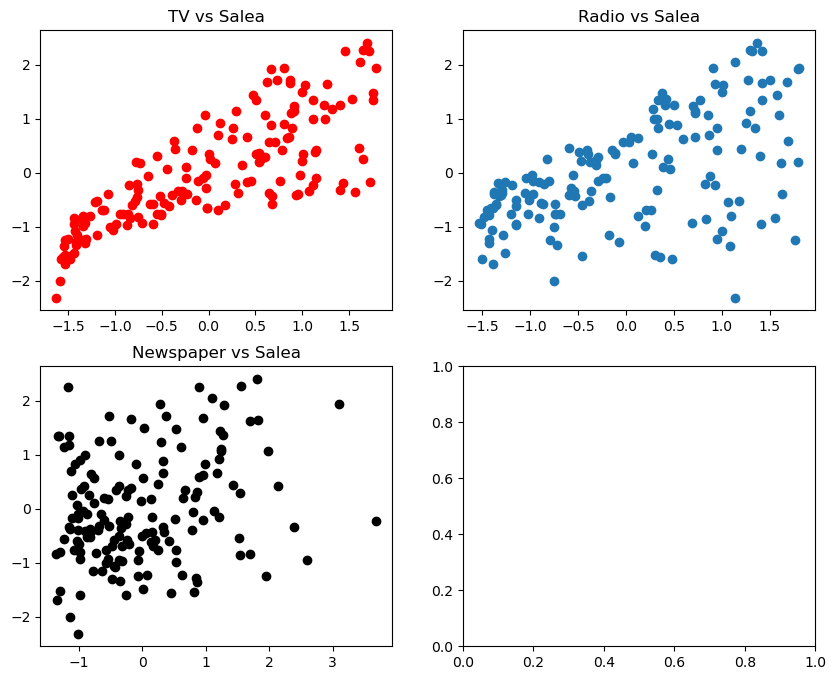

In [73]:
fig, ax = plt.subplots(2, 2,figsize=(10, 8))
ax[0,0].scatter(x_train[:,0], y_train, color = "r" )
ax[0, 0].set_title("TV vs Salea")
ax[0,1].scatter(x_train[:,1], y_train )
ax[0, 1].set_title("Radio vs Salea")
ax[1,0].scatter(x_train[:,2], y_train ,color = "black")
ax[1, 0].set_title("Newspaper vs Salea")

### Functions

In [74]:
#linear_regration
def linear_regression(x ,w):
    y_hat = 0
    for wi , xi  in zip(w , x.T):
        y_hat += xi * wi
    return y_hat
#gradian
def  gradient(x, y, y_hat):
     
    # 2/n *np.mean((x * (y_hat - y)**2))
    
    grads = []
    for xi in x.T :

        grads.append(2 * np.mean(xi * (y_hat - y)))
    grads = np.array(grads)
    
    return grads



    
#gradiangradian decint
def gradient_descent(w, eta, grads):
    w -= eta*grads

    return w       
def mse(y, y_hat):
    loss = np.mean((y - y_hat)**2)
    return loss

### main_for

In [75]:
n ,m = x_train.shape

In [76]:
x_train = np.hstack((np.ones((n, 1)), x_train))

In [77]:
w = np.random.randn(m+1)

eta = 0.01
n_epochs = 1000
error_hist = []

In [78]:
for epoch in range(n_epochs):
    y_hat =linear_regression(x_train , w)

    
    # loss
    e = mse(y_train, y_hat)
    error_hist.append(e)
    
    grads = gradient(x_train , y_train , y_hat)

    w = gradient_descent(w ,eta , grads)
    if (epoch+1) % 100 == 0:
        print(f'Epoch={epoch}, \t E={e:.4},\t w={w}')

Epoch=99, 	 E=0.2532,	 w=[0.10735296 0.45800226 0.69191879 0.02309397]
Epoch=199, 	 E=0.1119,	 w=[ 0.0142371   0.7246404   0.53845646 -0.01145597]
Epoch=299, 	 E=0.1089,	 w=[ 0.00188812  0.76244224  0.51297221 -0.00401074]
Epoch=399, 	 E=0.1088,	 w=[ 2.50401387e-04  7.67661339e-01  5.07316817e-01 -3.74171380e-04]
Epoch=499, 	 E=0.1088,	 w=[3.32081207e-05 7.68365330e-01 5.05868732e-01 8.25463349e-04]
Epoch=599, 	 E=0.1088,	 w=[4.40404622e-06 7.68456791e-01 5.05473791e-01 1.18865964e-03]
Epoch=699, 	 E=0.1088,	 w=[5.84062654e-07 7.68467713e-01 5.05362989e-01 1.29545528e-03]
Epoch=799, 	 E=0.1088,	 w=[7.74581302e-08 7.68468726e-01 5.05331493e-01 1.32648523e-03]
Epoch=899, 	 E=0.1088,	 w=[1.02724632e-08 7.68468724e-01 5.05322484e-01 1.33545324e-03]
Epoch=999, 	 E=0.1088,	 w=[1.36232992e-09 7.68468683e-01 5.05319900e-01 1.33803868e-03]


In [79]:
w

array([1.36232992e-09, 7.68468683e-01, 5.05319900e-01, 1.33803868e-03])

In [80]:
np.save('multiple-linear-regression-weights', w)

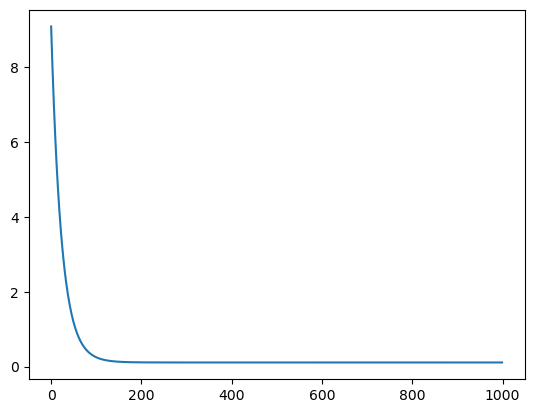

In [81]:
plt.plot(error_hist)

### test

In [82]:
df = pd.read_csv('test_advertising_data.csv')
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,0,0.847676,0.082803,-1.221651,0.715550
1,1,-0.072210,1.276778,0.649225,0.677183
2,2,0.912473,1.769208,-1.257372,2.115957
3,3,1.567385,1.762463,0.466156,2.557182
4,4,-1.121689,1.114883,0.613505,-0.627306
5,5,1.160090,1.027190,-0.364352,1.559631
6,6,-0.082623,-1.205612,-0.985001,-0.473836
7,7,0.332772,-1.009988,0.171460,-0.377918
8,8,-0.614884,0.183987,1.877127,-0.147714
9,9,0.574603,0.399847,-0.587607,0.696367


In [92]:
train_set = np.array(df)
d , f = x_test.shape
x_test = train_set[:,1:4]
y_test = train_set[:,4]
x_test.shape, y_test.shape
x_test = np.hstack((np.ones((d, 1)), x_test))

In [93]:
def mae(y, y_hat):
    loss = np.mean(np.abs(y - y_hat))
    return loss

In [94]:
def r2(y, y_hat):
    return 1 - np.sum((y - y_hat)**2) / np.sum((y - y.mean())**2)

In [95]:
w = np.load('multiple-linear-regression-weights.npy')
w

array([1.36232992e-09, 7.68468683e-01, 5.05319900e-01, 1.33803868e-03])

In [96]:
y_hat_test = linear_regression(x_test, w)

In [97]:
r2(y_test, y_hat_test)

0.9085777498402048

In [98]:
mse(y_test, y_hat_test)

0.0815937310070481